<a href="https://colab.research.google.com/github/wesleycsousa/AI_SCIENTIST_TECH-CHALLENGE_1/blob/main/EDA_NPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NPS no E-commerce

**Links importantes**

Base de dados do desafio

https://github.com/wesleycsousa/AI_SCIENTIST_TECH-CHALLENGE_1/blob/main/data/desafio_nps_fase_1.csv

O Net Promoter Score (NPS) é uma métrica amplamente utilizada para medir a satisfação e a lealdade dos clientes. Ele varia de 0 a 10 e representa a probabilidade de um cliente recomendar a empresa para outras pessoas. De forma geral, clientes são classificados como detratores (0 a 6), neutros (7 e 8) e promotores (9 e 10). Quanto maior o NPS, maior tende a ser o nível de satisfação e o potencial de crescimento do negócio.

No contexto de e-commerce, o NPS vai além de uma simples métrica de satisfação. Ele reflete toda a experiência do cliente ao longo da jornada, incluindo aspectos como entrega, atendimento, preço e qualidade do produto. Como essa métrica é coletada ao final da jornada, ela funciona como um indicador consolidado da experiência, mas não permite atuação preventiva direta, já que o problema já ocorreu quando a nota é registrada.

Dessa forma, analisar o NPS junto com dados operacionais — como tempo de entrega, atrasos, contatos com atendimento e resolução de problemas — permite identificar os principais fatores que impactam a experiência do cliente. O objetivo não é apenas entender a satisfação passada, mas encontrar padrões que ajudem a antecipar problemas e melhorar a operação de forma estratégica.

**Pergunta Norteadora**

"Quais fatores operacionais mais influenciam a satisfação do cliente e como podemos antecipar clientes com maior risco de se tornarem detratores?"

### 1 Import de bibliotecas e dataset

In [1]:
#Libs para calculo e manipulação de datasets
import pandas as pd
import numpy as np

#libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#Avisos
import warnings
warnings.filterwarnings('ignore')

In [63]:
# importar dados de NPS
# Caminho do arquivo no git pessoal
url = "https://raw.githubusercontent.com/wesleycsousa/AI_SCIENTIST_TECH-CHALLENGE_1/refs/heads/main/data/desafio_nps_fase_1.csv"

#ler arquivo CSV
nps = pd.read_csv(url)

# Visualização inicial de uma amostra de 10 registros
nps.sample(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
1717,1718,29,Centro-Oeste,86,51718,634.48,2,0.34,1,13,3,45.06,3,0,6,1.7,0,3,2.8
360,361,52,Norte,17,50361,140.96,3,6.84,6,13,1,25.31,3,0,6,8.8,1,1,4.5
299,300,38,Sudeste,109,50300,303.79,3,1.84,9,8,2,33.76,3,4,4,2.6,0,7,1.4
1841,1842,35,Nordeste,25,51842,781.26,1,17.98,4,7,3,20.20,2,1,9,4.2,0,5,1.2
270,271,59,Nordeste,80,50271,79.93,2,129.11,6,2,4,27.59,1,1,1,1.1,0,3,4.8
470,471,59,Sul,71,50471,254.47,5,8.47,2,13,4,21.93,2,4,2,0.0,0,6,0.8
64,65,63,Norte,64,50065,522.84,2,76.14,3,3,3,19.72,1,3,7,3.2,0,6,0.0
159,160,58,Sudeste,47,50160,221.05,2,17.25,3,5,2,48.59,2,1,5,6.9,0,4,3.6
1655,1656,40,Centro-Oeste,62,51656,324.49,5,58.37,1,5,2,38.72,1,0,10,4.5,0,2,1.1
2062,2063,50,Norte,17,52063,240.84,4,11.99,10,8,4,22.31,2,2,9,2.2,0,5,0.0


### 2 Entendimento do dataset e tratamento dos dados

In [3]:
# formato do dataset, quantidade de linhas e colunas
nps.shape

(2500, 19)

In [4]:
# colunas e tipagem
nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [64]:
# verificar existência de valores nulos
nps.isnull().sum().sum()
#obs: cenário muito ideal, normalmente existe dados nulos

np.int64(0)

In [65]:
# estatística das colunas numéricas para entender distribuição dos valores
nps.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [66]:
#identifica os valores únicos por coluna
nps.nunique()

,0
customer_id,2500
customer_age,52
customer_region,5
customer_tenure_months,119
order_id,2500
order_value,2457
items_quantity,6
discount_value,2050
payment_installments,11
delivery_time_days,13


### 3 Definição da Variável Target

A variável target foi definida a partir do NPS, classificando os clientes em dois grupos: detratores (nota ≤ 6) e não detratores (nota > 6). Para viabilizar a análise, essa classificação foi convertida em uma variável binária (is_detractor), onde 1 representa detrator e 0 representa não detrator.

Essa transformação simplifica a leitura e permite comparar diretamente os dois grupos ao longo das análises, facilitando a identificação de padrões de insatisfação. Além disso, o uso de 0 e 1 é um padrão amplamente utilizado em análises de dados, pois permite aplicar métricas estatísticas de forma direta (como médias e proporções), tornando os resultados mais claros e acionáveis do ponto de vista de negócio.

In [70]:
#definindo a variável target
nps['is_detractor'] = nps['nps_score'].apply(lambda x: 1 if x <= 6 else 0)

In [71]:
#proporção dos valores
nps['is_detractor'].value_counts(normalize=True)

,proportion
is_detractor,
1,0.7404
0,0.2596


Como tem muitos detratores, a base se mostra bastante desbalanceada. No caso de modelagem, precisaria tratar esse ponto.

### 4 Análise Exploratória Geral - Identificando variáveis correlatas

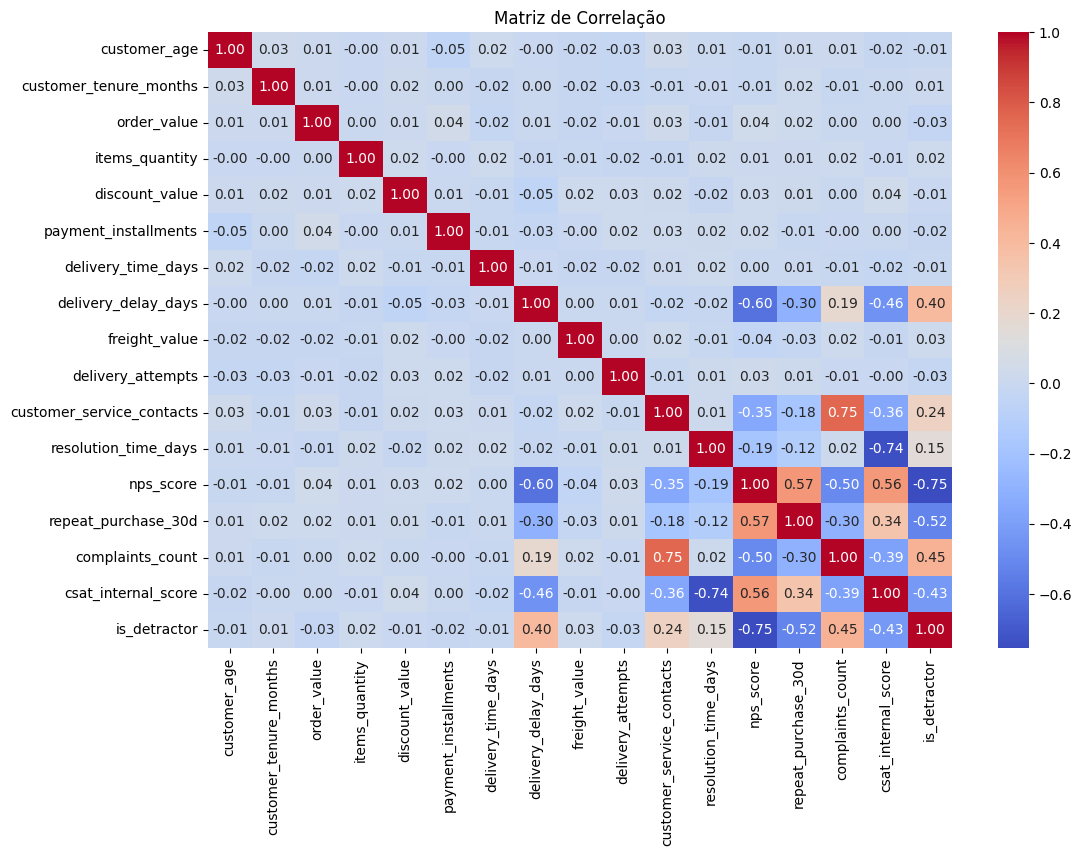

In [72]:
# head map com a matriz de correção
cols_to_drop = ['customer_id', 'order_id'] # eliminar colunas de Id
corr = nps.drop(columns=cols_to_drop).corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

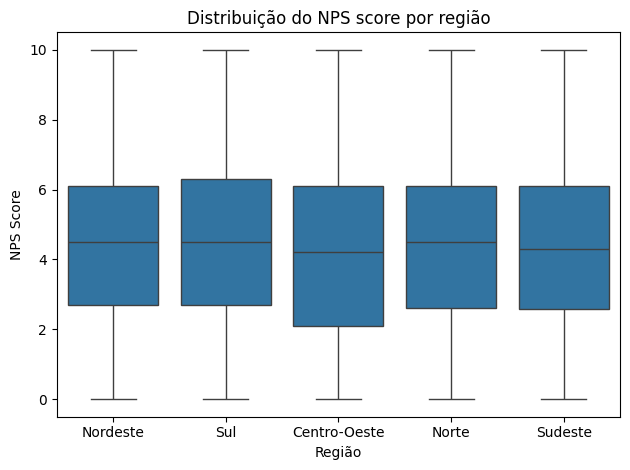

In [11]:
#avaliando distribuição de NPS por região
plt.figure()
sns.boxplot(data=nps, x="customer_region", y="nps_score") #municipio
plt.title("Distribuição do NPS score por região")
plt.xlabel("Região")
plt.ylabel("NPS Score")
plt.tight_layout()
plt.show()

O gráfico acima fornece uma dimensão de variáveis que podem ter alguma correlação (não causalidade) com o NPS. De maneira geral é possível identificar que existe correlação com as seguintes variáveis, que abaixo está agrupadas por tema:

Entrega
- delivery_delay_days (int)

Atendimento
- customer_service_contacts (int)
- resolution_time_days (int)
- complaints_count (int)
- csat_internal_score

Jornada
- repeat_purchase_30d

Essas variáveis serão analisadas com mais profundida nas sessões a seguir.

OBS: só existe uma variável categórica: região, onde não foi possível identificar diferente padrão do NPs, não sendo evidente relação direta.



### 5 Análise Exploratória dos Dados - entrega

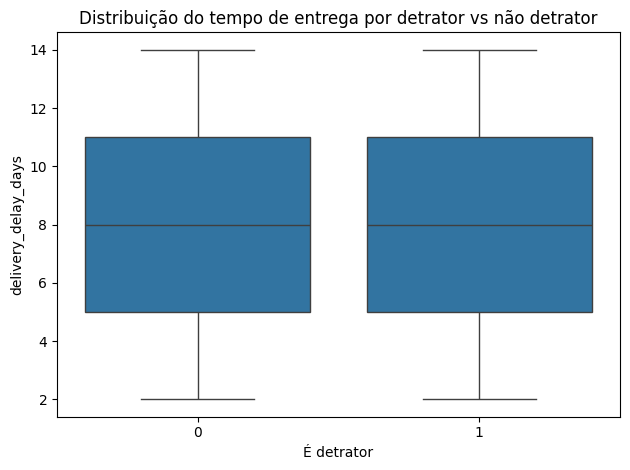

In [75]:
#entender distribuição da métrica de delivery_time_days por grupo
plt.figure()
sns.boxplot(data=nps, x="is_detractor", y="delivery_time_days")
plt.title("Distribuição do tempo de entrega por detrator vs não detrator")
plt.xlabel("É detrator")
plt.ylabel("delivery_delay_days")
plt.tight_layout()
plt.show()

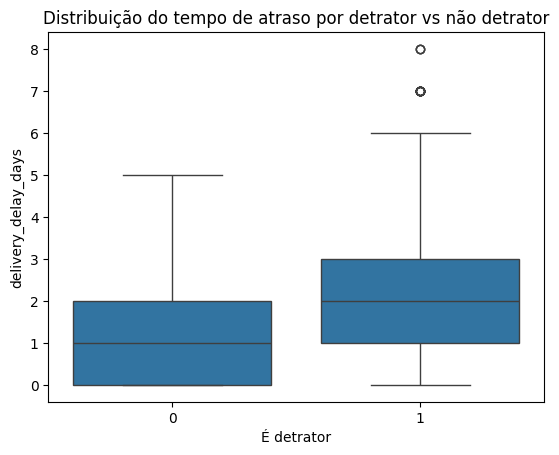

In [79]:
#entender distribuição da métrica de delivery_delay_days por grupo
plt.figure()
sns.boxplot(data=nps, x="is_detractor", y="delivery_delay_days") #municipio
plt.title("Distribuição do tempo de atraso por detrator vs não detrator")
plt.xlabel("É detrator")
plt.ylabel("delivery_delay_days")
plt.show()

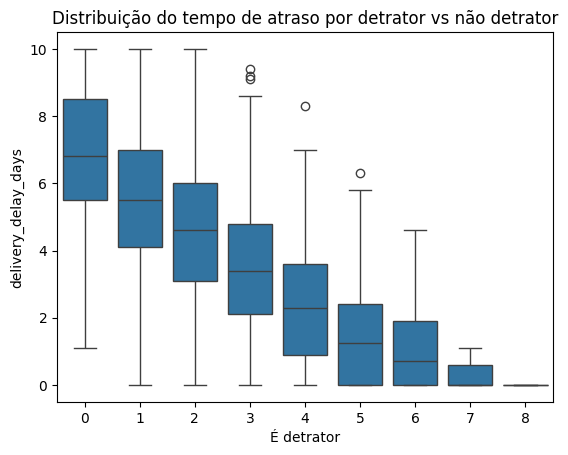

In [80]:
#entender distribuição da métrica de delivery_time_days por nota de nps
plt.figure()
sns.boxplot(data=nps, x="delivery_delay_days", y="nps_score") #municipio
plt.title("Distribuição do tempo de atraso por detrator vs não detrator")
plt.xlabel("É detrator")
plt.ylabel("delivery_delay_days")
#plt.tight_layout()
plt.show()

In [81]:
nps.groupby('is_detractor')['delivery_delay_days'].agg(
    mean='mean',
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
)

,mean,median,p25,p75
is_detractor,,,,
0,1.197227,1.0,0.0,2.0
1,2.534306,2.0,1.0,3.0


**Conclusão:**
Não foi observada uma relação relevante entre o tempo total de entrega e o NPS. No entanto, o atraso na entrega se mostrou um fator crítico: clientes não detratores apresentam, em média, atrasos menores (próximo de 1 dia), enquanto detratores concentram atrasos mais elevados (em torno de 2 dias ou mais). Isso indica que o problema não é o prazo em si, mas o descumprimento da expectativa, que impacta diretamente a satisfação.

**Recomendação:**
Monitorar e reduzir atrasos como KPI prioritário, com foco na consistência da entrega. Implementar alertas operacionais para pedidos com risco de atraso e priorizar sua resolução antes da quebra de expectativa do cliente.

### 5 Análise Expploratória - Atendimento

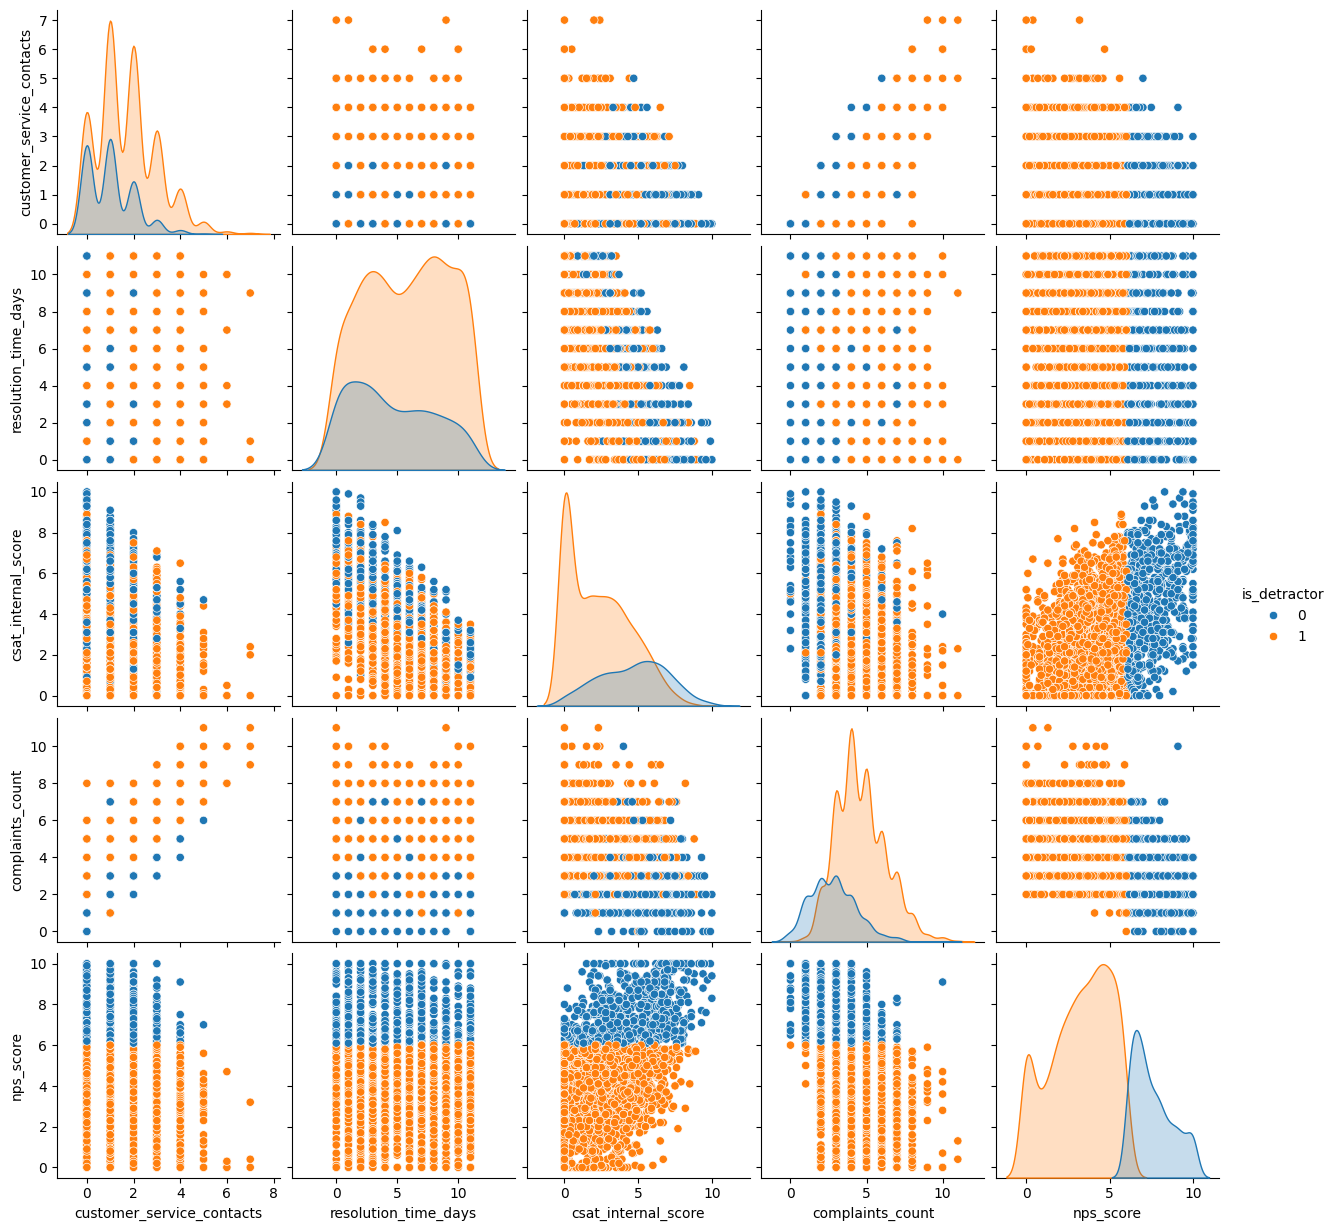

In [82]:
#cruzamento inicial para identificar as coreções
nps_atendimento = nps[['customer_service_contacts','resolution_time_days','csat_internal_score','complaints_count','nps_score','is_detractor']]
sns.pairplot(nps_atendimento, hue = 'is_detractor')

Dado que as variáveis apesar de quantitativas, são discretas, não é a melhor visualização avaliar em dispersão. Mais abaixo terá uma análise para cada par de variável.

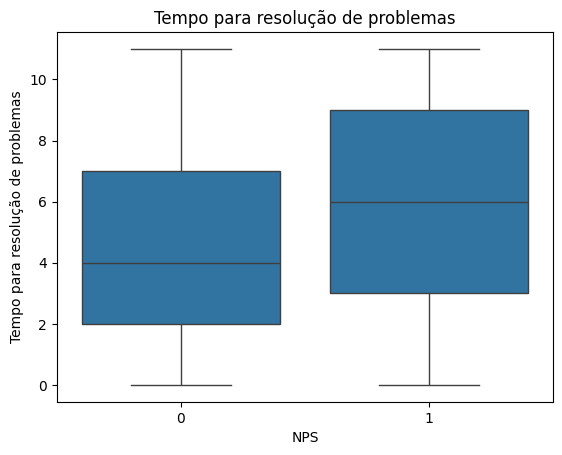

In [84]:

plt.figure()
sns.boxplot(data=nps, x="is_detractor", y="resolution_time_days") #municipio
plt.title("Tempo para resolução de problemas")
plt.xlabel("NPS")
plt.ylabel("Tempo para resolução de problemas")
plt.show()


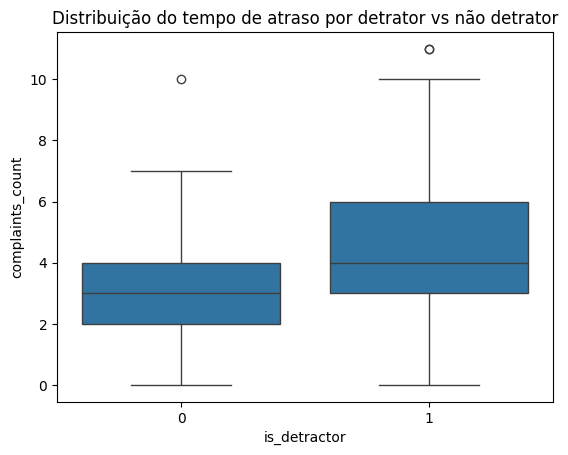

In [83]:
plt.figure()
sns.boxplot(data=nps, x="is_detractor", y="complaints_count") #municipio
plt.title("Distribuição do tempo de atraso por detrator vs não detrator")
plt.xlabel("is_detractor")
plt.ylabel("complaints_count")

plt.show()

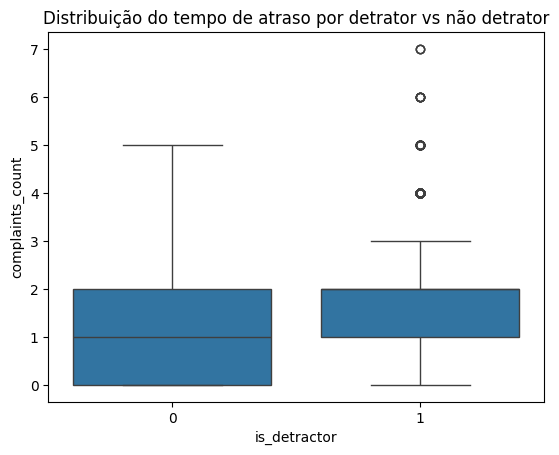

In [86]:
plt.figure()
sns.boxplot(data=nps, x="is_detractor", y="customer_service_contacts") #municipio
plt.title("Distribuição do tempo de atraso por detrator vs não detrator")
plt.xlabel("is_detractor")
plt.ylabel("complaints_count")
plt.show()

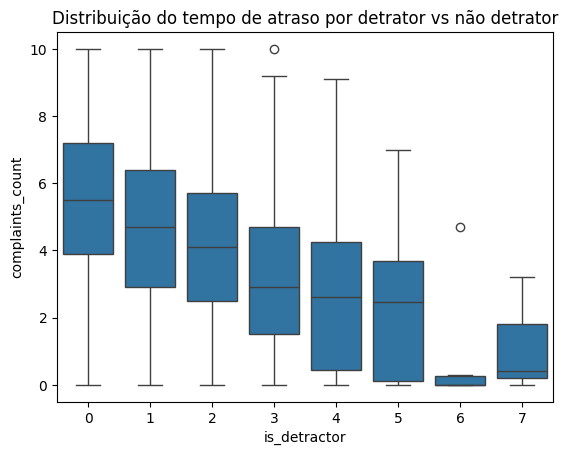

In [87]:
plt.figure()
sns.boxplot(data=nps, x="customer_service_contacts", y="nps_score") #municipio
plt.title("Distribuição do tempo de atraso por detrator vs não detrator")
plt.xlabel("is_detractor")
plt.ylabel("complaints_count")
plt.show()

**Conclusão:**
Foi identificada uma forte relação entre clientes detratores e variáveis ligadas ao atendimento, principalmente tempo de resolução, número de reclamações e quantidade de contatos com o suporte. Isso indica que a insatisfação não surge no atendimento em si, mas é consequência de falhas anteriores na jornada (especialmente operacionais), que acabam gerando fricção e necessidade de contato.

**Recomendação:**
Priorizar a redução da necessidade de contato, atuando na causa raiz (ex: problemas logísticos e de entrega) e criar alertas para clientes com múltiplos contatos ou reclamações, permitindo intervenção proativa antes da consolidação da insatisfação.

### 6 Análise exploratória - recompra

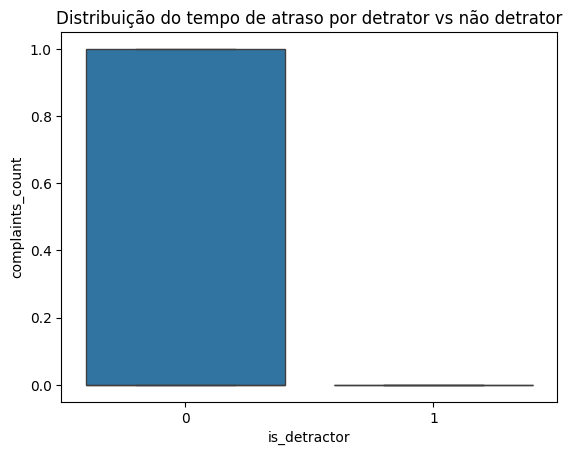

In [88]:
plt.figure()
sns.boxplot(data=nps, x="is_detractor", y="repeat_purchase_30d") #municipio
plt.title("Distribuição do tempo de atraso por detrator vs não detrator")
plt.xlabel("is_detractor")
plt.ylabel("complaints_count")
plt.show()

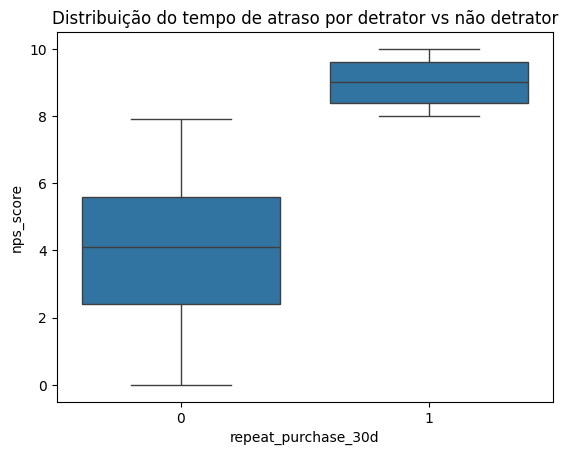

In [90]:
# como o gráfico anterior não ficou muito claro, foi realizado uma nova visualização para comparar a recompra vs nps_score
plt.figure()
sns.boxplot(data=nps, x="repeat_purchase_30d", y="nps_score") #municipio
plt.title("Distribuição do tempo de atraso por detrator vs não detrator")
plt.xlabel("repeat_purchase_30d")
plt.ylabel("nps_score")
plt.show()

In [91]:
nps.groupby('repeat_purchase_30d')['nps_score'].agg(
    mean='mean',
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
)

,mean,median,p25,p75
repeat_purchase_30d,,,,
0,3.936196,4.1,2.4,5.6
1,9.009633,9.0,8.4,9.6


**Conclusão:**
Clientes classificados como detratores apresentam probabilidade significativamente menor de realizar recompra nos 30 dias seguintes, indicando uma relação direta entre insatisfação e perda de receita no curto prazo.

**Recomendação:**
Criar ações de recuperação focadas em detratores logo após a experiência (ex: contato proativo, compensação ou resolução acelerada), com o objetivo de mitigar churn imediato e aumentar a chance de recompra.

### 7 Construção do Storytelliing

O Objetivo dessa sessão é trabalhar melhor a visualização dos gráficos, deixando os mais fáceis de serem lidos, alinhado com a apresentação final


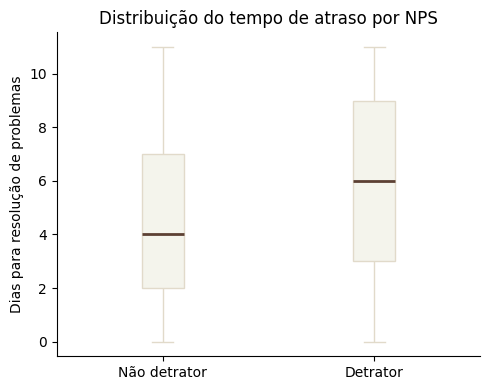

In [93]:

plt.figure(figsize=(5,4))

sns.boxplot(
    data=nps,
    x="is_detractor",
    y="resolution_time_days",
    width=0.2,
    palette=["#F5F5EB", "#F5F5EB"],  # bege claro
    medianprops={
        "color": "#5C4033",  # marrom escuro (foco)
        "linewidth": 2
    },
    boxprops={
        "edgecolor": "#E1DACA",  # linha da caixa mais clara
        "linewidth": 1
    },
    whiskerprops={
        "color": "#E1DACA",
        "linewidth": 1
    },
    capprops={
        "color": "#E1DACA",
        "linewidth": 1
    },

    flierprops={
        "marker": "o",
        "markerfacecolor": "#E1DACA",
        "markeredgecolor": "#E1DACA",
        "markersize": 4
    }
)

plt.title("Distribuição do tempo de atraso por NPS")
plt.xlabel("")
plt.ylabel("Dias para resolução de problemas")

plt.xticks([0, 1], ["Não detrator", "Detrator"])
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


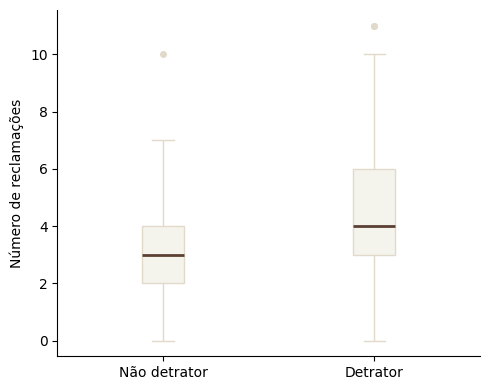

In [95]:


plt.figure(figsize=(5,4))

sns.boxplot(
    data=nps,
    x="is_detractor",
    y="complaints_count",
    width=0.2,
    palette=["#F5F5EB", "#F5F5EB"],  # bege claro
    medianprops={
        "color": "#5C4033",  # marrom escuro (foco)
        "linewidth": 2
    },
    boxprops={
        "edgecolor": "#E1DACA",  # linha da caixa mais clara
        "linewidth": 1
    },
    whiskerprops={
        "color": "#E1DACA",
        "linewidth": 1
    },
    capprops={
        "color": "#E1DACA",
        "linewidth": 1
    },

    flierprops={
        "marker": "o",
        "markerfacecolor": "#E1DACA",
        "markeredgecolor": "#E1DACA",
        "markersize": 4
    }
)

plt.xlabel("")
plt.ylabel("Número de reclamações")


plt.xticks([0, 1], ["Não detrator", "Detrator"])
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()





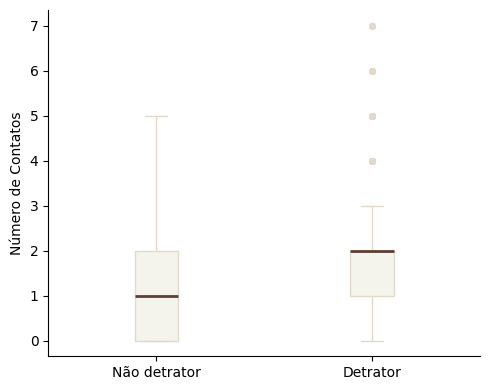

In [97]:


plt.figure(figsize=(5,4))

sns.boxplot(
    data=nps,
    x="is_detractor",
    y="customer_service_contacts",
    width=0.2,
    palette=["#F5F5EB", "#F5F5EB"],  # bege claro
    medianprops={
        "color": "#5C4033",  # marrom escuro (foco)
        "linewidth": 2
    },
    boxprops={
        "edgecolor": "#E1DACA",  # linha da caixa mais clara
        "linewidth": 1
    },
    whiskerprops={
        "color": "#E1DACA",
        "linewidth": 1
    },
    capprops={
        "color": "#E1DACA",
        "linewidth": 1
    },

    flierprops={
        "marker": "o",
        "markerfacecolor": "#E1DACA",
        "markeredgecolor": "#E1DACA",
        "markersize": 4
    }
)

plt.xlabel("")
plt.ylabel("Número de Contatos")


plt.xticks([0, 1], ["Não detrator", "Detrator"])
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


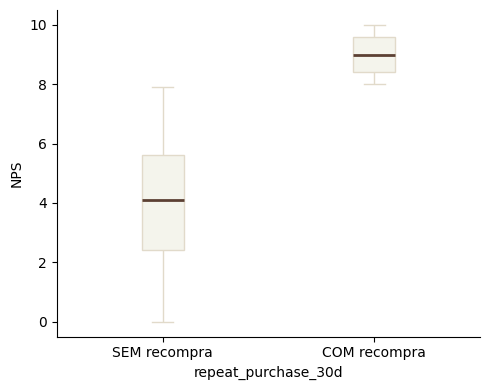

In [98]:

plt.figure(figsize=(5,4))

sns.boxplot(
    data=nps,
    x="repeat_purchase_30d",
    y="nps_score",
    width=0.2,
    palette=["#F5F5EB", "#F5F5EB"],  # bege claro
    medianprops={
        "color": "#5C4033",  # marrom escuro (foco)
        "linewidth": 2
    },
    boxprops={
        "edgecolor": "#E1DACA",  # linha da caixa mais clara
        "linewidth": 1
    },
    whiskerprops={
        "color": "#E1DACA",
        "linewidth": 1
    },
    capprops={
        "color": "#E1DACA",
        "linewidth": 1
    },

    flierprops={
        "marker": "o",
        "markerfacecolor": "#E1DACA",
        "markeredgecolor": "#E1DACA",
        "markersize": 4
    }
)

#plt.xlabel("se houve recompra em até 30 dias") // não necessário porque é autoexplicativo
plt.ylabel("NPS")

# Ajustar rótulos do eixo X
plt.xticks([0, 1], ["SEM recompra", "COM recompra"])

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()





